# PyTorch Fundamentals — Reference Notebook

A full worked run-through: Tensors → Autograd → `nn.Module` & Losses → Optimizers & the Training
Loop. Companion explanations (the math, the "why," common misconceptions, practice questions) live
in [`docs/`](docs/README.md) — this notebook is the hands-on, runnable half.

This is a **reference copy**, kept separate from [`pytorch_notes.ipynb`](pytorch_notes.ipynb) (the
personal working-notes notebook) so the two don't collide. Read through this one, then keep
exploring/extending in your own notes at your own pace — copy over whatever's useful.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
print("torch", torch.__version__)
print("mps available:", torch.backends.mps.is_available())

torch 2.13.0
mps available: True


# Tensors

Tensors are the building block of everything in PyTorch — every input, weight, activation, and
gradient a model touches is a tensor. A tensor is a multi-dimensional array of numbers, like a
NumPy array, but with two extra abilities NumPy doesn't have: it can live on a GPU/MPS device, and
PyTorch can automatically track operations on it to compute gradients later (see the Autograd
section below).

Full mechanism, the `view`-vs-`reshape` distinction, broadcasting rules, and the NumPy
shared-memory gotcha: [`docs/01_tensors.md`](docs/01_tensors.md).

## Creating tensors from data

In [2]:
# from a Python list — dtype is INFERRED from the data
int_tensor = torch.tensor([1, 2, 3])
float_tensor = torch.tensor([1.0, 2.0, 3.0])
print("int_tensor.dtype:", int_tensor.dtype)
print("float_tensor.dtype:", float_tensor.dtype)

# a nested list becomes a 2D tensor, same mechanism — a small pixel-grid example
grid = torch.tensor([
    [0, 0, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 1, 1, 0, 0],
])
print("grid:\n", grid)
print("grid.dtype:", grid.dtype, "grid.shape:", grid.shape)

int_tensor.dtype: torch.int64
float_tensor.dtype: torch.float32
grid:
 tensor([[0, 0, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 1, 0],
        [0, 0, 1, 1, 0, 0]])
grid.dtype: torch.int64 grid.shape: torch.Size([5, 6])


## Shape-first creation

You specify the *shape*, PyTorch fills in the values — this is exactly how a model's weights get
their starting values before any training happens (`nn.Linear` uses `torch.randn`-style
initialization internally, scaled by a formula depending on layer size).

In [3]:
shape = (2, 3)
zeros = torch.zeros(shape)
ones = torch.ones(shape)
randn = torch.randn(shape)   # standard normal — real weight initialization
arange = torch.arange(10)

print("zeros:\n", zeros)
print("ones:\n", ones)
print("randn:\n", randn)
print("arange:", arange)

t = torch.randn(2, 3)
print("\ndtype:", t.dtype, "shape:", t.shape, "device:", t.device)

zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
randn:
 tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986]])
arange: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

dtype: torch.float32 shape: torch.Size([2, 3]) device: cpu


## Indexing and slicing — same rules as NumPy

In [4]:
print("row 0:", grid[0])
print("column 0:", grid[:, 0])
print("center 3x3 block:\n", grid[1:4, 1:4])
print("how many 1s total:", grid.sum().item())

row 0: tensor([0, 0, 1, 1, 0, 0])
column 0: tensor([0, 0, 1, 0, 0])
center 3x3 block:
 tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])
how many 1s total: 18


## `view` vs `reshape` — a real, checkable difference, not two names for the same thing

A tensor's data lives in one flat block of memory; `shape` + `stride` together describe how to
read that flat memory as a multi-dimensional array. `.view()` only works when the tensor is
**contiguous** (reinterprets memory layout, no copy); `.reshape()` uses `.view()`'s cheap path when
possible and silently copies when it isn't. Full mechanism:
[`docs/01_tensors.md`](docs/01_tensors.md#indexing-slicing-reshaping--and-the-viewreshape-distinction-that-actually-matters).

In [5]:
a = torch.arange(6).reshape(2, 3)
print("a:\n", a, "\nstride:", a.stride(), "contiguous:", a.is_contiguous())

b = a.t()   # transpose — a VIEW, no data copied, but no longer contiguous
print("\nb = a.t():\n", b, "\nstride:", b.stride(), "contiguous:", b.is_contiguous())

try:
    b.view(6)
except RuntimeError as e:
    print("\nb.view(6) fails:", e)

c = b.reshape(6)   # works — falls back to copying when a view isn't possible
print("\nb.reshape(6) works:", c)

a:
 tensor([[0, 1, 2],
        [3, 4, 5]]) 
stride: (3, 1) contiguous: True

b = a.t():
 tensor([[0, 3],
        [1, 4],
        [2, 5]]) 
stride: (1, 3) contiguous: False

b.view(6) fails: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

b.reshape(6) works: tensor([0, 3, 1, 4, 2, 5])


## Broadcasting

Operations between tensors of different (but compatible) shapes automatically expand the smaller
one — no explicit copying. The rule: compare shapes from the *right*; dimensions are compatible
if equal, or one of them is 1 (or missing).

In [6]:
m = torch.ones(3, 4)
v = torch.tensor([1., 2., 3., 4.])   # shape (4,)
result = m + v
print("m.shape:", m.shape, "v.shape:", v.shape, "-> result.shape:", result.shape)
print(result)

m.shape: torch.Size([3, 4]) v.shape: torch.Size([4]) -> result.shape: torch.Size([3, 4])
tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])


## NumPy interop — a real shared-memory gotcha

On CPU, `.numpy()` and `torch.from_numpy()` don't copy — they share memory. Convenient, and a real
footgun if you don't know it's happening.

In [7]:
t = torch.ones(3)
n = t.numpy()
t.add_(1)   # in-place op on the tensor
print("numpy array after in-place torch op:", n)   # changed too — same memory, not a copy

numpy array after in-place torch op: [2. 2. 2.]


# Autograd

Training means adjusting weights to reduce a loss — which requires the loss's gradient with
respect to every weight. Autograd computes all of them automatically by recording every operation
on a `requires_grad=True` tensor as it happens (a dynamic computation graph, built during actual
execution), then walking that graph backward once `.backward()` is called.

Full mechanism, the leaf-tensor/`grad_fn` distinction, and why in-place ops can break the graph:
[`docs/02_autograd.md`](docs/02_autograd.md).

## A hand-verified example — worth checking by hand once

`z = xy + x²` → `∂z/∂x = y + 2x`, `∂z/∂y = x`. At `x=2, y=3`: `∂z/∂x = 7`, `∂z/∂y = 2`.

In [8]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = (x * y) + x**2
print("z:", z.item())

z.backward()
print("dz/dx:", x.grad.item(), "(expected 7.0)")
print("dz/dy:", y.grad.item(), "(expected 2.0)")

# leaf vs non-leaf, grad_fn
print("\nx.is_leaf:", x.is_leaf, " z.is_leaf:", z.is_leaf)
print("z.grad_fn:", z.grad_fn)

z: 10.0
dz/dx: 7.0 (expected 7.0)
dz/dy: 2.0 (expected 2.0)

x.is_leaf: True  z.is_leaf: False
z.grad_fn: <AddBackward0 object at 0x1140ed4b0>


## Gradients accumulate — `.backward()` never resets `.grad` for you

This is a feature (it's what makes gradient accumulation possible), and also the most common real
training bug (forgetting `optimizer.zero_grad()`).

In [9]:
x2 = torch.tensor(1.0, requires_grad=True)
for i in range(3):
    loss = x2 ** 2
    loss.backward()
    print(f"iter {i}: x2.grad = {x2.grad.item()}  (adding up, not overwriting)")

iter 0: x2.grad = 2.0  (adding up, not overwriting)
iter 1: x2.grad = 4.0  (adding up, not overwriting)
iter 2: x2.grad = 6.0  (adding up, not overwriting)


## In-place ops can break the graph — enforced, not just a warning

Autograd sometimes needs a tensor's *original* value during backward. Modifying it in place first
overwrites that value, so PyTorch raises loudly rather than silently returning a wrong gradient.

In [10]:
e = torch.tensor(2.0, requires_grad=True)
f = e * e
try:
    e.add_(1)      # modifying a leaf tensor that's needed for f's backward pass
    f.backward()
except RuntimeError as err:
    print("RuntimeError:", err)

RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.


## `torch.no_grad()` and `.detach()` — two ways to step outside the graph

In [11]:
g = torch.tensor(3.0, requires_grad=True)
with torch.no_grad():
    h = g * 2
print("h.requires_grad under no_grad():", h.requires_grad)

i_ = g.detach()
print("i_.requires_grad:", i_.requires_grad, " shares memory with g:", i_.data_ptr() == g.data_ptr())

h.requires_grad under no_grad(): False
i_.requires_grad: False  shares memory with g: True


# `nn.Module` and Losses

A real model has many weight tensors that need to be created, tracked, moved to a device together,
and saved/loaded together. `nn.Module` is PyTorch's base class for organizing that: register
layers/parameters in `__init__`, define the forward computation in `forward()` — PyTorch finds
every parameter, moves them all with one `.to()` call, and saves/loads them all together,
automatically.

Full mechanism, the `model(x)` vs `model.forward(x)` hook difference, and the
`CrossEntropyLoss` logits gotcha: [`docs/03_nn_module_and_losses.md`](docs/03_nn_module_and_losses.md).

In [12]:
class TinyMLP(nn.Module):
    def __init__(self, in_features, hidden, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = TinyMLP(4, 8, 2)
print("parameters:")
for name, p in model.named_parameters():
    print(" ", name, tuple(p.shape))

print("\nstate_dict keys:", list(model.state_dict().keys()))

parameters:
  fc1.weight (8, 4)
  fc1.bias (8,)
  fc2.weight (2, 8)
  fc2.bias (2,)

state_dict keys: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']


## `model(x)`, not `model.forward(x)` — a real, checkable difference

`model(x)` runs PyTorch's own bookkeeping around `forward()`, including firing registered hooks.
Calling `.forward()` directly skips that bookkeeping entirely.

In [13]:
x = torch.randn(3, 4)

fired = []
hook_handle = model.register_forward_hook(lambda module, inp, out: fired.append(True))

fired.clear()
model(x)
print("hook fired via model(x):", len(fired) == 1)

fired.clear()
model.forward(x)
print("hook fired via model.forward(x):", len(fired) == 1, "(should be False)")

hook_handle.remove()

hook fired via model(x): True
hook fired via model.forward(x): False (should be False)


## Losses: `MSELoss` is exactly what it sounds like; `CrossEntropyLoss` has a real gotcha

`CrossEntropyLoss` expects raw **logits** (not softmax'd probabilities) and class **indices**
(not one-hot vectors) — it applies `log_softmax` internally itself.

In [14]:
mse = nn.MSELoss()
pred = torch.tensor([2.0, 3.0])
targ = torch.tensor([1.0, 5.0])
print("MSE:", mse(pred, targ).item(), "(expected 2.5 = mean of 1^2 and 2^2)")

logits = torch.randn(5, 3)
target = torch.tensor([0, 2, 1, 1, 0])   # class indices, NOT one-hot
loss_builtin = nn.CrossEntropyLoss()(logits, target)
loss_manual = F.nll_loss(F.log_softmax(logits, dim=1), target)
print("CrossEntropyLoss matches manual log_softmax+nll:", torch.allclose(loss_builtin, loss_manual))

MSE: 2.5 (expected 2.5 = mean of 1^2 and 2^2)
CrossEntropyLoss matches manual log_softmax+nll: True


# Optimizers and the Training Loop

Autograd computes gradients; it doesn't *use* them. An optimizer takes a computed gradient and
actually updates each parameter. The training loop is that update, repeated: forward → loss →
backward → step.

Full mechanism, SGD vs AdamW, and why `zero_grad()` must come first:
[`docs/04_optimizers_and_training_loop.md`](docs/04_optimizers_and_training_loop.md).

## The loop, on real data — linear regression `y = 2x + 3 + noise`

In [15]:
torch.manual_seed(0)
X = torch.linspace(-5, 5, 200).unsqueeze(1)
y_true = 2 * X + 3 + torch.randn_like(X) * 0.5

reg_model = nn.Linear(1, 1)
optimizer = torch.optim.SGD(reg_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

losses = []
for step in range(200):
    optimizer.zero_grad()        # clear accumulated gradients first
    pred = reg_model(X)          # forward pass
    loss = loss_fn(pred, y_true) # how wrong is the model right now
    loss.backward()              # compute gradients
    optimizer.step()             # actually update the parameters
    losses.append(loss.item())

print("first loss:", losses[0], " last loss:", losses[-1])
w, b = reg_model.weight.item(), reg_model.bias.item()
print(f"learned w={w:.3f} (true 2.0), b={b:.3f} (true 3.0)")

first loss: 76.97571563720703  last loss: 0.23460762202739716
learned w=1.984 (true 2.0), b=2.927 (true 3.0)


## The visual step — plot the loss curve, don't just trust the final number

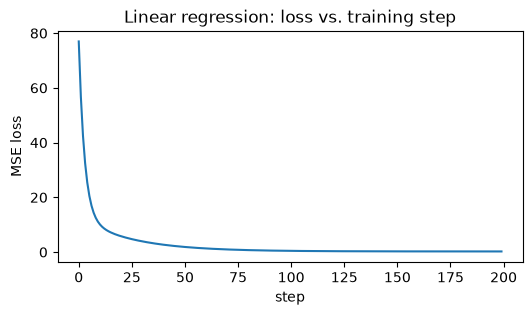

In [16]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("Linear regression: loss vs. training step")
plt.show()

## `model.train()` / `model.eval()` — not about gradients, about layer *behavior*

Unrelated to `torch.no_grad()`. Some layers (`Dropout`, `BatchNorm`) genuinely behave differently
depending on this switch.

In [17]:
class DropoutDemo(nn.Module):
    def __init__(self):
        super().__init__()
        self.drop = nn.Dropout(0.5)
    def forward(self, x):
        return self.drop(x)

dm = DropoutDemo()
x = torch.ones(10)

dm.train()
print("train mode (dropout active, survivors scaled by 1/(1-p)=2):", dm(x))

dm.eval()
print("eval mode (dropout off, unscaled passthrough):           ", dm(x))

train mode (dropout active, survivors scaled by 1/(1-p)=2): tensor([2., 0., 2., 0., 2., 0., 2., 2., 2., 0.])
eval mode (dropout off, unscaled passthrough):            tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## The memorization sanity check — a real debugging technique

Can the model perfectly memorize a *tiny* slice of data if trained on nothing else long enough?
If not, something's wrong in the model/loss/data pipeline before generalization is even worth
worrying about. Uses `AdamW` (decoupled weight decay — see
[`docs/04_optimizers_and_training_loop.md`](docs/04_optimizers_and_training_loop.md) for why
that's the default over plain `Adam` in most training scripts in this workspace).

In [18]:
torch.manual_seed(0)
X_tiny = torch.randn(8, 4)
y_tiny = torch.randint(0, 2, (8,))

tiny_model = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 2))
optimizer = torch.optim.AdamW(tiny_model.parameters(), lr=0.01)

for step in range(300):
    optimizer.zero_grad()
    logits = tiny_model(X_tiny)
    loss = F.cross_entropy(logits, y_tiny)
    loss.backward()
    optimizer.step()

final_acc = (tiny_model(X_tiny).argmax(dim=1) == y_tiny).float().mean().item()
print("memorization accuracy on the 8 training examples:", final_acc, "(should be 1.0)")
print("final loss:", loss.item())

memorization accuracy on the 8 training examples: 1.0 (should be 1.0)
final loss: 0.0008304413058795035


## Where to go next

Try It Yourself prompts for each section (extending the pixel-grid example, breaking the
memorization check on purpose, comparing SGD vs AdamW convergence speed, and more) are in each
chapter of [`docs/`](docs/README.md) — that's the natural next step in your own exploration.

This exact four-step loop (`zero_grad → forward → loss → backward → step`) is what trains every
larger model in this workspace, too — see
[`mini-llms-playground/from_scratch/tinystories-gpt-6m/train.py`](../../mini-llms-playground/from_scratch/tinystories-gpt-6m/train.py)
for the same mechanism at real-model scale (gradient accumulation, mixed precision, LR
scheduling, checkpointing all layered on top of exactly this loop), and
[`mini-llms-playground/docs/llm-engineering/13_the_training_loop_mechanism_by_mechanism.md`](../../mini-llms-playground/docs/llm-engineering/13_the_training_loop_mechanism_by_mechanism.md)
for that layering explained mechanism by mechanism.